# 07. Results & Error Analysis

This notebook loads the predictions saved by `05_evaluation.ipynb` and produces
the visual analysis i.e. predicted-vs-true plots, confusion matrices, and a close
look at the model's worst errors. The analysis reveals two things worth more
than the headline Spearman: the model is a reasonable *ranker* but a poor
*calibrator* (regression to the mean), and a meaningful fraction of its
"errors" are actually label noise in the dataset.

In [2]:
import sys, os
sys.path.append("../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from config import FIG_DIR

sns.set_theme(style="whitegrid")

RESULTS_DIR = "../results"
MODELS = {
    "DistilBERT (66M)":    "distilbert_128",
    "RoBERTa-base (125M)": "roberta_base_128",
    "RoBERTa-large (355M)":"roberta_large_128",
}

preds = {}
for label, fname in MODELS.items():
    path = os.path.join(RESULTS_DIR, f"predictions_{fname}.csv")
    preds[label] = pd.read_csv(path)
    print(f"{label}: {len(preds[label]):,} rows loaded")

DistilBERT (66M): 41,957 rows loaded
RoBERTa-base (125M): 41,957 rows loaded
RoBERTa-large (355M): 41,957 rows loaded


## Predicted vs. true score

The ideal model would follow the diagonal i.e. predicted score equals true score.
In practice, all three models show regression to the mean i.e. the mean
prediction rises with the true score, but is far flatter than the diagonal.
Predictions are compressed into the 1–5 range; the models never confidently
predict the extremes.

This is expected for MSE regression on an imbalanced target. Confidently
predicting a rare extreme that the noisy label might disagree with is
penalized heavily, so the model hedges toward the safe middle.

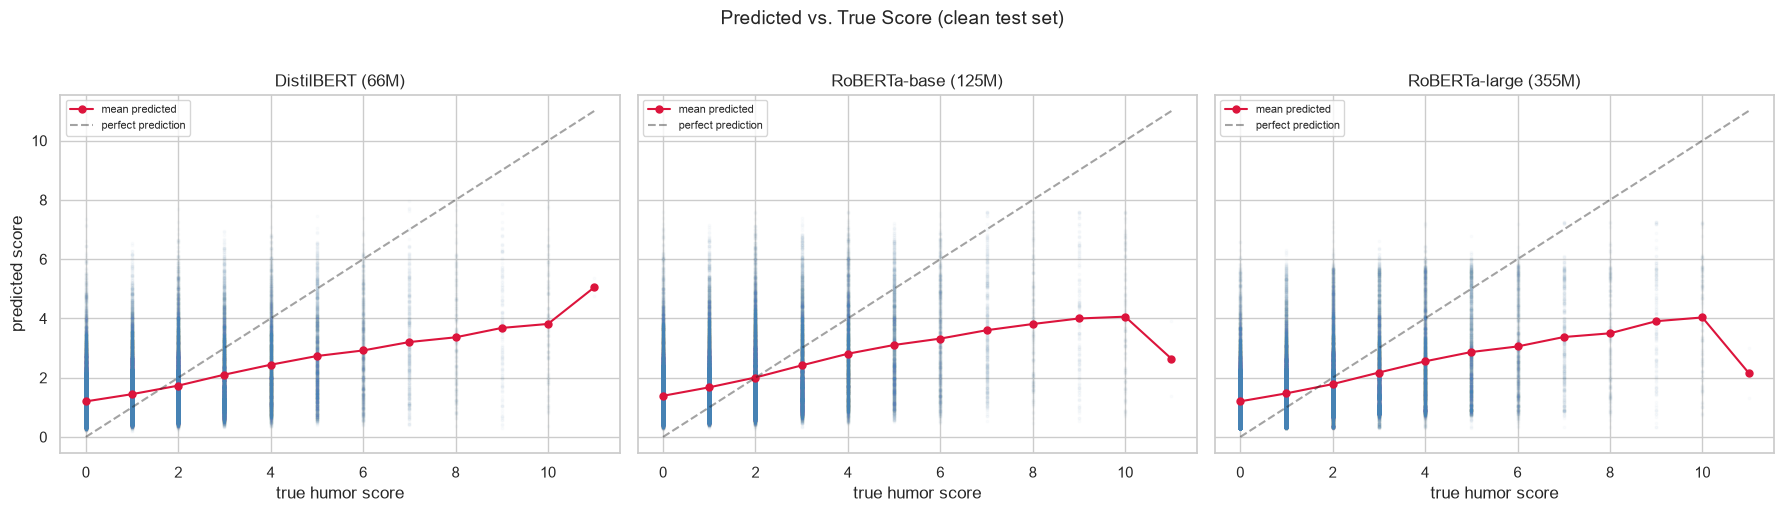

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (label, df) in zip(axes, preds.items()):
    means = df.groupby("score")["pred"].mean()

    ax.scatter(df["score"], df["pred"], alpha=0.02, s=3, color="steelblue")
    ax.plot(means.index, means.values, "o-", color="crimson", markersize=5,
            label="mean predicted")
    ax.plot([0, 11], [0, 11], "k--", alpha=0.4, label="perfect prediction")
    ax.set_xlabel("true humor score")
    ax.set_title(label)
    ax.legend(fontsize=8)

axes[0].set_ylabel("predicted score")
plt.suptitle("Predicted vs. True Score (clean test set)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "07_pred_vs_true_all.png", dpi=150, bbox_inches="tight")
plt.show()

## Confusion matrix

To see where the models succeed and fail in concrete terms, we bucket both
predictions and true scores into four classes and compute a confusion matrix.
The models are strong on the common middle classes (mild, funny) and
essentially never predict the extremes (not funny, very funny).

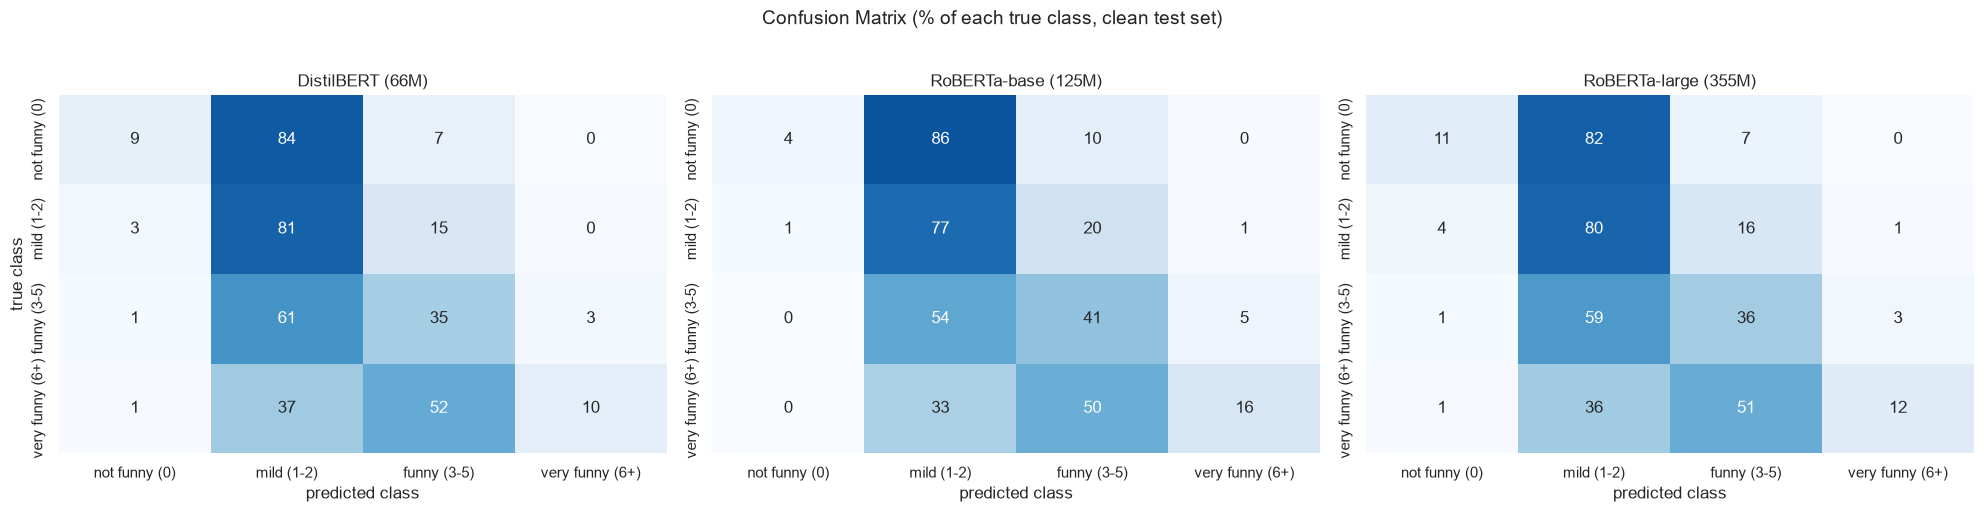

In [4]:
def to_bucket(s):
    if s < 0.5:   return "not funny (0)"
    elif s < 2.5: return "mild (1-2)"
    elif s < 5.5: return "funny (3-5)"
    else:         return "very funny (6+)"

ORDER = ["not funny (0)", "mild (1-2)", "funny (3-5)", "very funny (6+)"]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, (label, df) in zip(axes, preds.items()):
    true_b = df["score"].apply(to_bucket)
    pred_b = df["pred"].apply(to_bucket)
    cm = confusion_matrix(true_b, pred_b, labels=ORDER)
    cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100

    sns.heatmap(cm_pct, annot=True, fmt=".0f", cmap="Blues",
                xticklabels=ORDER, yticklabels=ORDER, ax=ax,
                vmin=0, vmax=100, cbar=False)
    ax.set_xlabel("predicted class")
    ax.set_title(label)

axes[0].set_ylabel("true class")
plt.suptitle("Confusion Matrix (% of each true class, clean test set)",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "07_confusion_all.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
# macro-F1
for label, df in preds.items():
    true_b = df["score"].apply(to_bucket)
    pred_b = df["pred"].apply(to_bucket)
    report = classification_report(true_b, pred_b, labels=ORDER,
                                   output_dict=True, zero_division=0)
    print(f"{label:30s}  macro-F1 = {report['macro avg']['f1-score']:.3f}")

DistilBERT (66M)                macro-F1 = 0.310
RoBERTa-base (125M)             macro-F1 = 0.305
RoBERTa-large (355M)            macro-F1 = 0.328


## Worst misses

The largest errors (highest absolute difference between prediction and true
score) fall into two informative categories:

1. **Label noise.** Some jokes the model rates highly but labeled 0, including
   cases where the joke's own text suggests it was popular. These are likely
   mislabeled due to Reddit-specific artifacts (deleted/reposted, score reset).
   The model isn't wrong; the label is.

2. **Genuinely hard humor.** Short, culturally specific one-liners that require
   world knowledge a small model can't be expected to have. These represent a
   real capability ceiling.

The implication is that the dataset's label noise is itself part of the performance
ceiling. No model can perfectly predict a target that is partly arbitrary.

In [6]:
# show worst misses for RoBERTa-large
best = preds["RoBERTa-large (355M)"].copy()
best["error"] = (best["pred"] - best["score"]).abs()
worst = best.nlargest(10, "error")

print("Top 10 worst misses (RoBERTa-large, clean test)\n")
for _, row in worst.iterrows():
    print(f"  true={int(row['score']):>2d}  pred={row['pred']:.1f}  "
          f"error={row['error']:.1f}")
    print(f"  {row['joke'][:500]}...")
    print()

Top 10 worst misses (RoBERTa-large, clean test)

  true=11  pred=1.3  error=9.7
  Ajit Pai. That's it. That's the whole fucking joke.  EDIT: Removed edits, people don't like those. [](/rdcry)...

  true=10  pred=0.8  error=9.2
  Online classified ad Premature ejaculator in need of smoking hot size 6 blonde.   Preferably with blue eyes and huge double d....  Nevermind. ...

  true=10  pred=0.8  error=9.2
  Did you hear about McDonald's trying to get into the high end steakhouse market? It was a Big Mcsteak...

  true=10  pred=0.8  error=9.2
  Billie Eilish is officially 18 now, do you know what that means? She's old enough to order 12 fascinating issues of Zoobooks for $19.95 if she calls 1-800-441-2400. When she calls, they'll include the bonus Elephants issue, stickers, and Tiger Poster with her order....

  true=10  pred=1.0  error=9.0
  My tongue slipped when I was asking my wife to "pass the milk, honey" when we had breakfast yesterday I accidentally said: "Fuck you Helen you ruine

## Do the models disagree?

Do the three models make the *same* errors, or do they fail on
different jokes? High overlap in worst misses across models suggests the errors
come from the dataset rather than model-specific weaknesses.

In [8]:
# overlap of top-100 worst misses across models
worst_sets = {}
for label, df in preds.items():
    df = df.copy()
    df["error"] = (df["pred"] - df["score"]).abs()
    worst_sets[label] = set(df.nlargest(100, "error").index)

labels = list(worst_sets.keys())
for i in range(len(labels)):
    for j in range(i+1, len(labels)):
        overlap = len(worst_sets[labels[i]] & worst_sets[labels[j]])
        print(f"{labels[i]:30s} ∩ {labels[j]:30s} = {overlap}/100")

DistilBERT (66M)               ∩ RoBERTa-base (125M)            = 68/100
DistilBERT (66M)               ∩ RoBERTa-large (355M)           = 65/100
RoBERTa-base (125M)            ∩ RoBERTa-large (355M)           = 71/100


## Summary

The models form a clear ladder: TF-IDF (0.363) → DistilBERT (0.412) →
RoBERTa-base (0.419) → RoBERTa-large (0.432). But all share the same
qualitative behavior:

- **Regression to the mean:** predictions clustered in the 1–5 range, never
  confidently predicting the extremes.
- **Strong on common classes, weak on rare ones:** macro-F1 is low because the
  models essentially never predict "not funny" or "very funny."
- **Label noise as a ceiling:** a meaningful fraction of the worst errors are
  dataset artifacts, not model failures.

These patterns are consistent across model sizes, suggesting they reflect
properties of the task and dataset rather than any single model's limitations.
The full metrics table and leakage analysis are in `05_evaluation.ipynb`.